<a href="https://colab.research.google.com/github/Sneha8126/Sneha-copy-of-Sample-ML-Submission-Template/blob/main/Sneha_copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual

Name : Sneha

Branch : CSE - C

Roll Number : 51420802724

# **Project Summary -**

Write the summary here within 500-600 words.

The objective of this project was to develop a machine learning model capable of accurately predicting taxi trip prices based on various trip-related factors. Accurate fare prediction is an essential component of modern ride-hailing and taxi services, as it helps companies implement transparent pricing strategies, optimize revenue, and improve customer satisfaction. The project aimed to analyze the relationship between different trip attributes and taxi fares while identifying the most suitable machine learning model for fare prediction.

The project began with an in-depth understanding of the dataset, which contained several important features such as Trip Distance, Time of Day, Day of Week, Passenger Count, Traffic Conditions, Weather, Base Fare, Per Kilometer Rate, Per Minute Rate, Trip Duration, and the target variable Trip Price. Initially, the dataset was explored to understand its structure, data types, missing values, and statistical properties. A missing value heatmap was created to visualize incomplete records, and appropriate preprocessing techniques were applied to improve data quality.

During the data preprocessing stage, missing values were handled using median imputation for numerical variables and mode imputation for categorical variables. Outliers were examined and treated where necessary to reduce their impact on model performance. Categorical variables were converted into numerical form using One-Hot Encoding, making the dataset compatible with machine learning algorithms. Finally, the processed dataset was divided into 80% training data and 20% testing data, ensuring that the models could be trained effectively and evaluated on unseen data.

Exploratory Data Analysis (EDA) was performed using a variety of visualizations, including histograms, bar charts, boxplots, scatter plots, line charts, correlation heatmaps, pair plots, and other customized graphs. These visualizations provided valuable business insights into the factors affecting taxi fares. The analysis revealed that Trip Distance, Trip Duration, Base Fare, Per Kilometer Rate, and Per Minute Rate were the most influential variables in determining the final trip price. Weather and traffic conditions also showed a noticeable impact on fare variations, while passenger count and time-based factors contributed moderately.

Three regression models were developed and compared: Linear Regression, Lasso Regression, and Ridge Regression. Each model was evaluated using standard regression metrics, including R² Score, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). To improve model reliability and reduce the possibility of overfitting, 5-Fold Cross Validation and GridSearchCV were applied for hyperparameter tuning. These techniques helped identify the optimal model configurations and ensured stable performance across different data splits.

After comparing the performance of all three models, Linear Regression emerged as the best-performing model for this dataset. It achieved the highest R² Score (approximately 0.892) while maintaining low MAE, MSE, and RMSE values, indicating strong predictive accuracy and good generalization capability. Model explainability was further enhanced by analyzing the regression coefficients, which highlighted the most influential features affecting taxi trip prices.

Overall, this project demonstrates that machine learning can effectively predict taxi trip prices using historical trip information. The developed prediction model can help taxi companies and ride-hailing platforms estimate fares more accurately, improve pricing transparency, support revenue optimization, and enhance customer satisfaction. The project also highlights the importance of data preprocessing, exploratory data analysis, model comparison, and hyperparameter optimization in building reliable and business-oriented machine learning solutions.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Accurate taxi fare estimation is essential for ensuring transparent pricing, improving customer satisfaction, and supporting efficient transportation services. Taxi trip prices are influenced by various factors such as trip distance, travel duration, traffic conditions, weather, passenger count, and time of travel, making manual fare estimation difficult and inconsistent. The objective of this project is to develop a machine learning regression model that predicts taxi trip prices based on these trip-related features. By analyzing historical trip data and identifying the key factors affecting fare prices, the model aims to provide accurate fare predictions that can assist taxi service providers in pricing trips fairly and optimizing their operations.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [239]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [240]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [241]:
df = pd.read_csv('/content/drive/MyDrive/taxi_trip_pricing.csv')
eda_df = df.copy()

### Dataset First View

In [242]:
# Dataset First Look
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


### Dataset Rows & Columns count

In [243]:
# Dataset Rows & Columns count
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 11


### Dataset Information

In [244]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


#### Duplicate Values

In [245]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [246]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


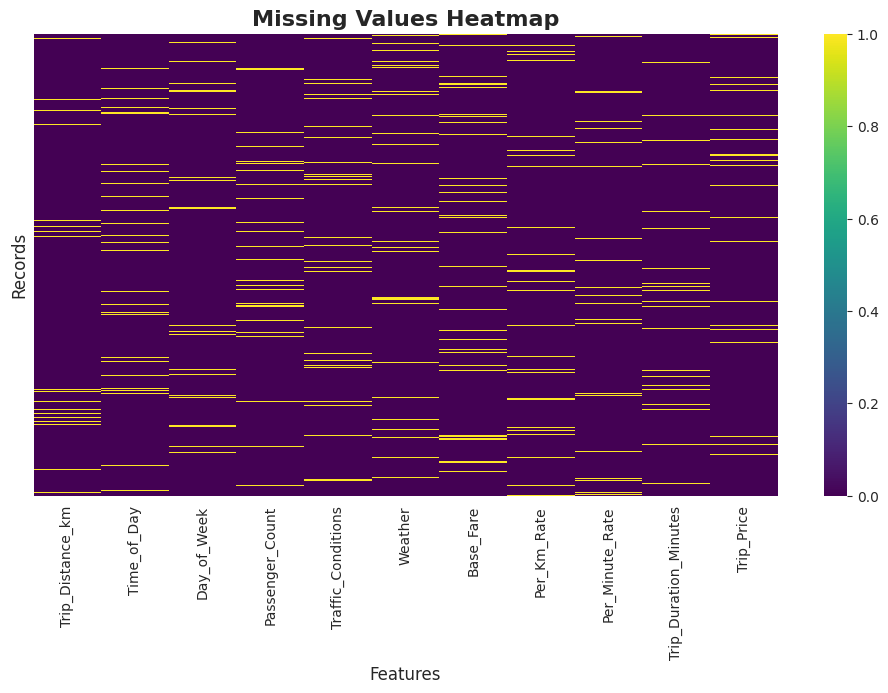

In [247]:
# Missing Values Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='viridis',
    yticklabels=False
)

plt.title('Missing Values Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Records', fontsize=12)

plt.show()

### What did you know about your dataset?

* The dataset contains historical taxi trip information and is designed for predicting taxi trip prices.

* It consists of 1,000 records and 11 features, including both numerical and categorical variables.

* The target variable is Trip-Price, making this a supervised machine learning regression problem.

* The dataset includes important trip-related features such as trip distance, trip duration, passenger count, traffic conditions, weather, time of day, day of the week, base fare, per-kilometer rate, and per-minute rate.

* Both numerical and categorical features are present, so preprocessing steps such as handling missing values and encoding categorical variables are required.

* A few columns contain missing values, which need to be treated before model training.

* The dataset is suitable for Exploratory Data Analysis (EDA) to identify relationships between trip characteristics and taxi fares.

## ***2. Understanding Your Variables***

In [248]:
# Dataset Columns
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [249]:
# Dataset Describe
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


### Variables Description

* **Trip_Distance_km:** Represents the total distance traveled during the taxi trip in kilometers.

* **Time_of_Day:** Indicates the time period when the trip took place (e.g., Morning, Afternoon, Evening, Night).

* **Day_of_Week:** Specifies the day on which the taxi trip occurred.

* **Passenger_Count:** Shows the number of passengers traveling in the taxi.

* **Traffic_Conditions:** Describes the traffic level during the trip (e.g., Low, Medium, High).

* **Weather:** Represents the weather conditions during the trip, such as Clear, Rainy, or Snowy.

* **Base_Fare:** The fixed starting fare charged for the taxi trip before additional costs.

* **Per_Km_Rate:** The fare charged for every kilometer traveled.

* **Per_Minute_Rate:** The fare charged for each minute of trip duration.

* **Trip_Duration_Minutes:** Indicates the total time taken to complete the taxi trip in minutes.

* **Trip_Price (Target Variable):** Represents the final fare of the taxi trip.

### Check Unique Values for each variable.

In [250]:
# Check Unique Values for each variable.
df.nunique()

,0
Trip_Distance_km,867
Time_of_Day,4
Day_of_Week,2
Passenger_Count,4
Traffic_Conditions,3
Weather,3
Base_Fare,290
Per_Km_Rate,150
Per_Minute_Rate,41
Trip_Duration_Minutes,917


## 3. ***Data Wrangling***

### Data Wrangling Code

In [251]:
df.shape

(1000, 11)

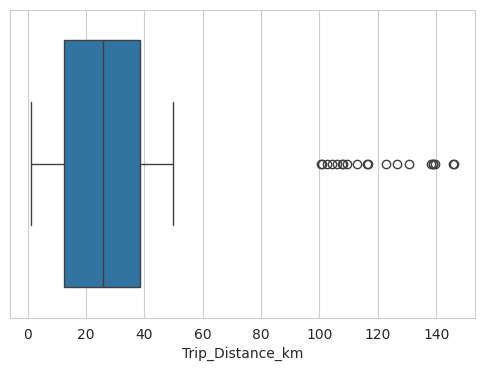

In [252]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Trip_Distance_km'])
plt.show()

In [253]:
# Write your code to make your dataset analysis ready.

df.dropna(subset=['Trip_Price'],inplace=True)

num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
  if col!='Trip_Price':
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

In [254]:
# Verify missing values
print(df.isnull().sum())

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


### What all manipulations have you done and insights you found?

* Checked the dataset for duplicate records to ensure data consistency and avoid redundant observations.

* Identified missing values in the dataset and calculated their percentage for each column.

* Filled missing values in categorical columns using the mode and in the numerical column using the median to preserve the data distribution.

* Verified that all missing values were handled successfully before proceeding with further analysis.

* Reviewed the dataset structure and data quality to ensure it was ready for exploratory data analysis and machine learning.

* After data wrangling, the dataset became cleaner, more consistent, and suitable for building an accurate freight cost prediction model.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

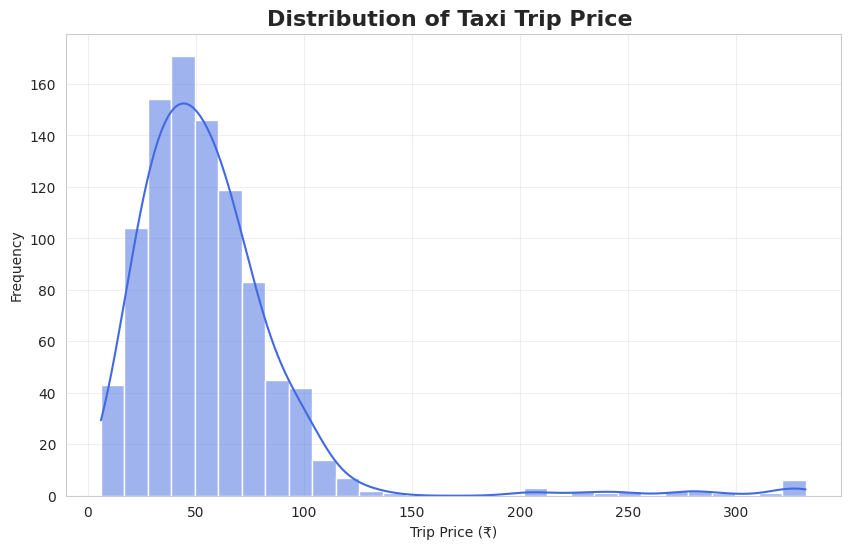

In [255]:
# Chart - 1 visualization code
plt.figure(figsize=(10,6))

sns.histplot(
    data=eda_df ,
    x='Trip_Price',
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title('Distribution of Taxi Trip Price ', fontsize=16, fontweight='bold')
plt.xlabel('Trip Price (₹)')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is suitable for visualizing the distribution of the target variable (Trip-Price). It helps identify the overall spread, central tendency, skewness, and potential outliers in taxi fares.

##### 2. What is/are the insight(s) found from the chart?

* Shows how taxi trip prices are distributed.

* Helps identify whether most fares are concentrated within a specific price range.

* Reveals whether the distribution is symmetric or skewed.

* Highlights possible high-value fare outliers.

##### 3. Will the gained insights help creating a positive business impact?

* Helps taxi companies understand common fare ranges.

* Useful for identifying unusually expensive trips that may require validation.
* Supports pricing analysis and demand forecasting.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* A small number of very high-priced trips (outliers) may indicate inconsistent pricing, which could reduce customer trust if fares appear unpredictable.

* If a large proportion of trips are concentrated in the lower fare range, it may suggest that the business relies mainly on short-distance trips, limiting overall revenue growth.

#### Chart - 2

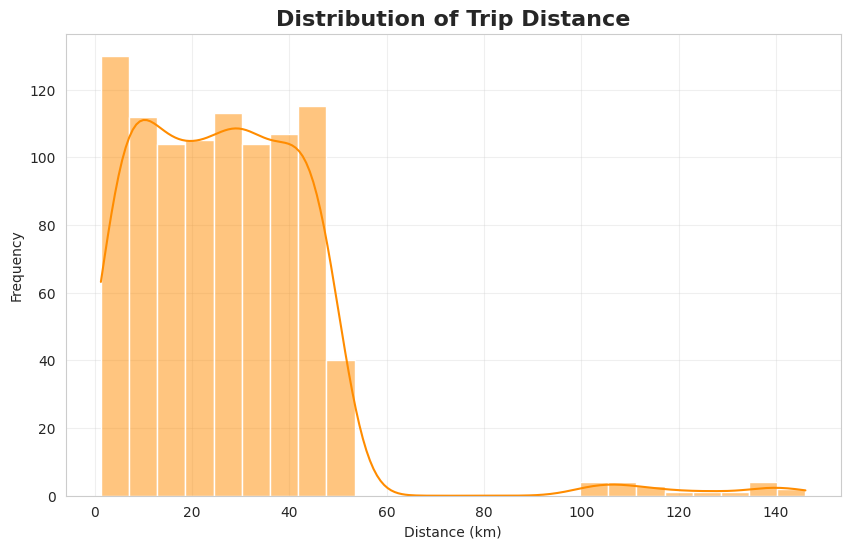

In [256]:
# Chart - 2 visualization code
plt.figure(figsize=(10,6))

sns.histplot(
    data=eda_df ,
    x='Trip_Distance_km',
    bins=25,
    kde=True,
    color='darkorange'
)

plt.title('Distribution of Trip Distance', fontsize=16, fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram effectively shows how trip distances are distributed across all taxi rides and whether short or long trips are more common.

##### 2. What is/are the insight(s) found from the chart?

* Most taxi trips may fall within a limited distance range.
* Long-distance trips are less frequent.

##### 3. Will the gained insights help creating a positive business impact?

* Supports fuel consumption and operational planning.
* Assists in designing distance-based pricing strategies.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* A high concentration of short-distance trips may limit overall revenue, as these trips generate lower fares compared to longer journeys.
* If long-distance trips are very few, it may indicate missed opportunities to increase revenue through higher-value rides.

#### Chart - 3

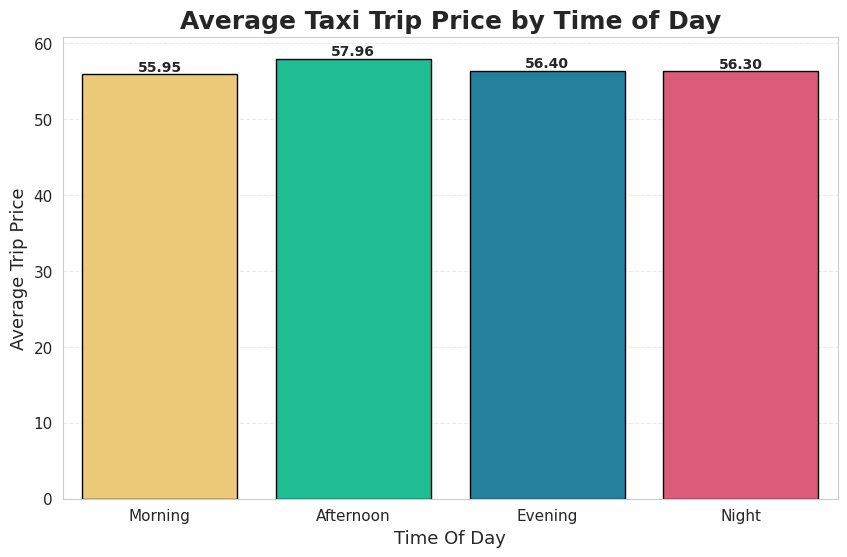

In [257]:
from matplotlib.lines import lineStyles
# Chart - 3 visualization code

# Average Trip Price by Time of Day

plt.figure(figsize=(10,6))
colors = ['#FFD166', '#06D6A0', '#118AB2', '#EF476F']
ax = sns.barplot(
    data=eda_df ,
    x='Time_of_Day',
    y='Trip_Price',
    estimator='mean',
    hue='Time_of_Day',
    palette=colors,
    edgecolor='black',
    legend=False,
    errorbar=None
)

for container in ax.containers:
  ax.bar_label(container,fmt='%.2f',fontsize=10,fontweight='bold')

plt.title('Average Taxi Trip Price by Time of Day',fontsize=18,fontweight='bold')
plt.xlabel('Time Of Day',fontsize=13)
plt.ylabel('Average Trip Price',fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.show()

##### 1. Why did you pick the specific chart?

* A bar chart is ideal for comparing the average trip price across different time periods of the day.
* It clearly highlights which time of day generates higher or lower taxi fares.
* It allows easy comparison between multiple categorical groups.

##### 2. What is/are the insight(s) found from the chart?

* The average taxi fare varies across different times of the day.
* Time of travel appears to influence fare pricing, likely due to changes in demand and traffic conditions.
* The chart helps identify peak periods when taxi fares are generally higher.

##### 3. Will the gained insights help creating a positive business impact?

* Taxi companies can implement dynamic pricing during high-demand periods.
* Drivers can be scheduled more efficiently during time slots with higher average fares.
* Customers can be informed about expected fare variations throughout the day.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* Time periods with consistently lower average fares may generate less revenue for drivers and taxi operators.
* If too many trips occur during low-fare periods, overall profitability may decrease.

#### Chart - 4

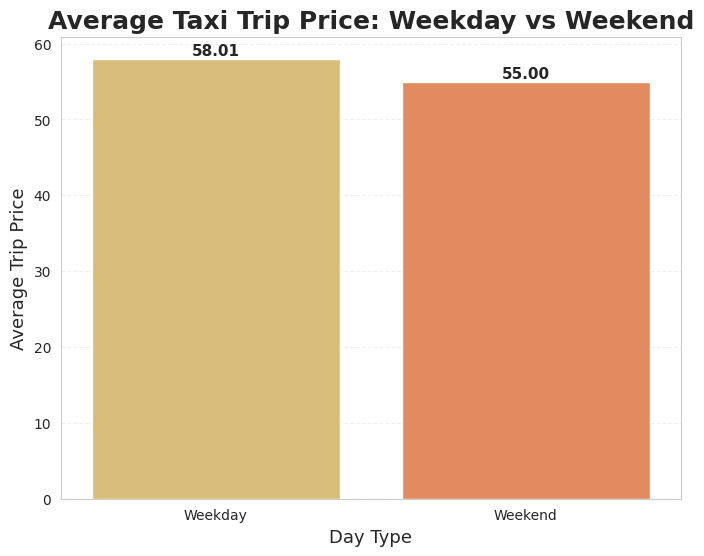

In [258]:
# Chart - 4 visualization code

# Chart 4: Average Trip Price by Day of Week

plt.figure(figsize=(8,6))

colors = ['#E9C46A', '#F9844A']

ax = sns.barplot(
    data=eda_df ,
    x='Day_of_Week',
    y='Trip_Price',
    estimator='mean',
    hue='Day_of_Week',
    palette=colors,
    legend=False,
    errorbar=None
)

# Value Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=11, fontweight='bold')

plt.title('Average Taxi Trip Price: Weekday vs Weekend',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Day Type', fontsize=13)
plt.ylabel('Average Trip Price', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A bar chart is ideal for comparing the average trip prices between two categories: Weekday and Weekend.
* It provides a clear visual comparison of average fares across different day types.


##### 2. What is/are the insight(s) found from the chart?

* The average taxi trip price differs between Weekdays and Weekends.
* The variation suggests that customer demand and trip characteristics change based on the day type.
* Day type is an important factor that can influence taxi pricing.

##### 3. Will the gained insights help creating a positive business impact?

* Taxi operators can optimize driver availability based on the day type with higher average fares.
* Businesses can implement dynamic pricing during periods with higher demand.
* Promotional offers can be introduced on lower-demand days to increase bookings.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* If one day type consistently generates lower average fares, it may reduce overall revenue.
* Depending heavily on only one day type for higher earnings may create inconsistent revenue throughout the week.

#### Chart - 5

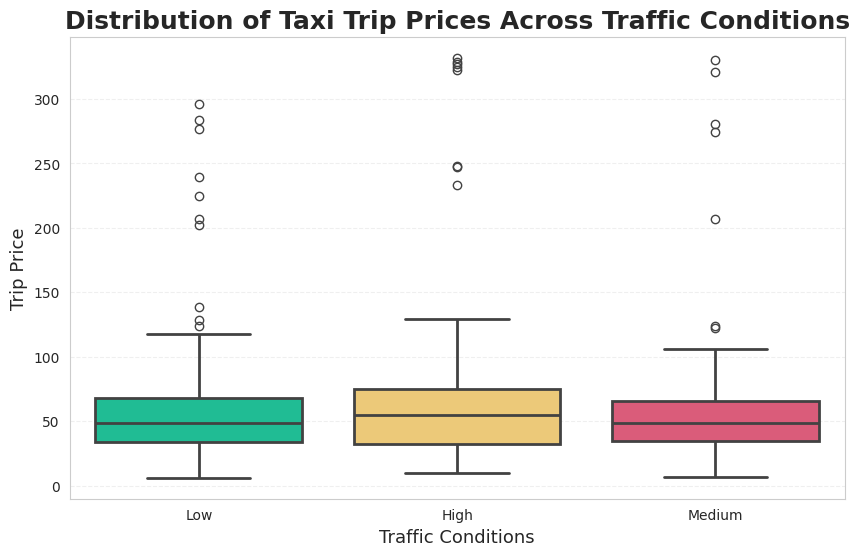

In [259]:
# Chart - 5 visualization code

# Chart 5: Trip Price Distribution by Traffic Conditions

plt.figure(figsize=(10,6))
colors = ['#06D6A0', '#FFD166', '#EF476F']
ax = sns.boxplot(
    data=eda_df ,x='Traffic_Conditions',y='Trip_Price',hue='Traffic_Conditions',palette=colors,legend=False,linewidth=2
)

plt.title('Distribution of Taxi Trip Prices Across Traffic Conditions',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Traffic Conditions', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

* A box plot is ideal for comparing the distribution of trip prices across different traffic conditions.
* It clearly displays the median, quartiles, spread, and outliers for each traffic category.
* It helps identify whether traffic conditions significantly affect taxi fares.

##### 2. What is/are the insight(s) found from the chart?

* Trip prices vary across different traffic conditions.

* Higher traffic conditions may be associated with greater fare variability due to longer travel times.

* The spread of trip prices differs between traffic categories, indicating changes in fare consistency.

##### 3. Will the gained insights help creating a positive business impact?


* Taxi companies can improve fare estimation by considering traffic conditions.
* Drivers can be assigned more efficiently during high-traffic periods.
* Better traffic-based planning can improve customer satisfaction and operational efficiency.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* Heavy traffic can increase trip duration, reducing the number of trips a driver can complete in a day.
* Frequent traffic congestion can increase fuel consumption and operating costs, reducing profitability.
* If customers consistently face higher fares due to traffic, they may switch to alternative transportation options.

#### Chart - 6

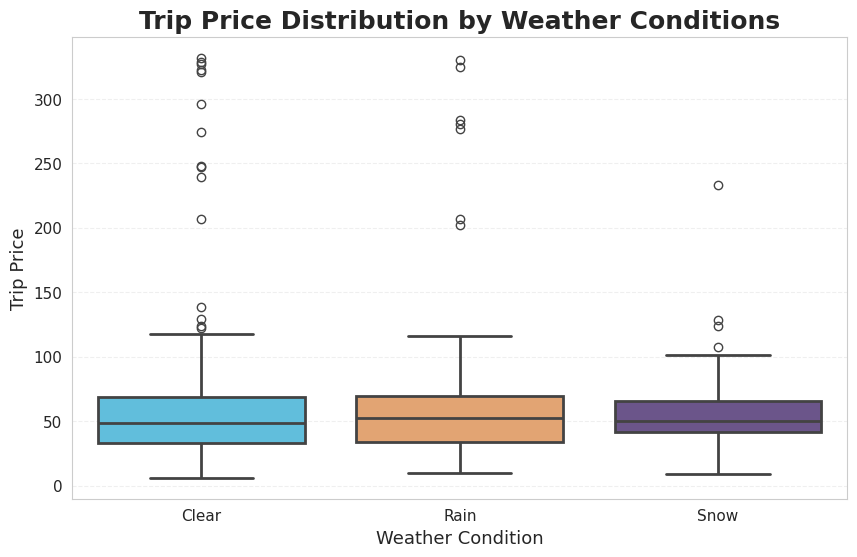

In [260]:
# Chart - 6 visualization code

# Chart 6: Trip Price Distribution by Weather Conditions

plt.figure(figsize=(10,6))

colors = ['#4CC9F0', '#F4A261', '#6A4C93']   # Clear, Rain, Snow

ax = sns.boxplot(
    data=eda_df ,
    x='Weather',
    y='Trip_Price',
    hue='Weather',
    palette=colors,
    legend=False,
    linewidth=2,
    showfliers=True
)

plt.title('Trip Price Distribution by Weather Conditions',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Weather Condition', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A box plot is the best choice for comparing trip price distributions across different weather conditions.

* It helps identify whether weather has a significant impact on taxi fares.

* It enables easy comparison of fare variability between different weather conditions.




##### 2. What is/are the insight(s) found from the chart?

* Trip prices vary across different weather conditions.
* Some weather conditions show a higher median trip price, indicating increased travel costs.
* The spread of trip prices differs among weather categories, suggesting that weather influences fare variability.

##### 3. Will the gained insights help creating a positive business impact?

* Taxi companies can improve fare prediction by including weather as a pricing factor.
* Fleet managers can deploy more vehicles during adverse weather when demand is likely to increase.

4. Are there any insights that lead to negative growth? Justify with specific reason.

* Severe weather conditions may reduce the number of customers willing to travel, decreasing trip volume.
* Adverse weather can increase trip duration and operational costs, lowering overall efficiency.

#### Chart - 7

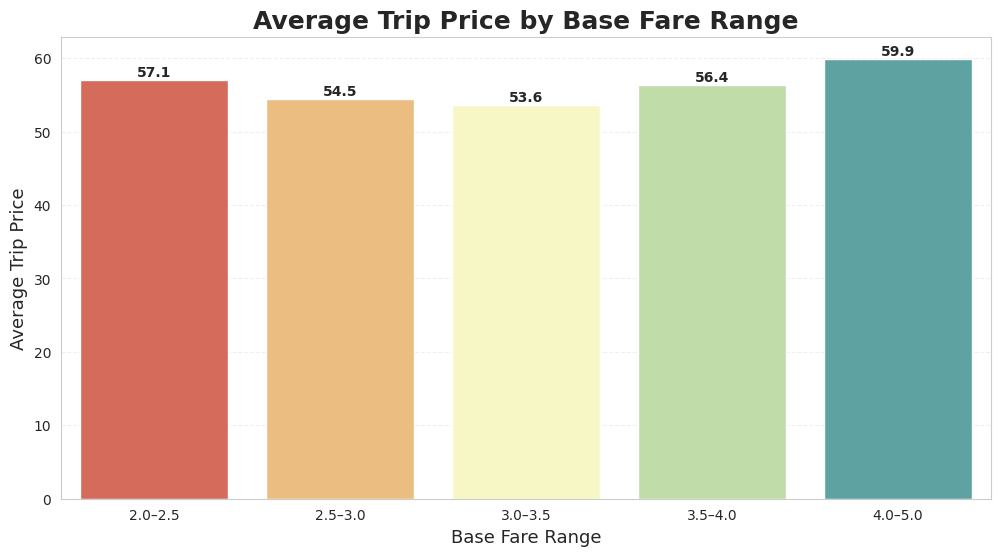

In [261]:
plt.figure(figsize=(12,6))

# Meaningful Base Fare Ranges
bins = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
labels = [
    '2.0–2.5',
    '2.5–3.0',
    '3.0–3.5',
    '3.5–4.0',
    '4.0–5.0'
]

df['Base_Fare_Group'] = pd.cut(
    df['Base_Fare'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

ax = sns.barplot(
    data=df,
    x='Base_Fare_Group',
    y='Trip_Price',
    estimator='mean',
    hue='Base_Fare_Group',
    palette='Spectral',
    legend=False,
    errorbar=None
)

# Value Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=10, fontweight='bold')

plt.title('Average Trip Price by Base Fare Range',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Base Fare Range', fontsize=13)
plt.ylabel('Average Trip Price', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A grouped bar chart effectively compares the average trip price across different base fare ranges.
* It helps visualize how changes in the base fare influence the final trip price.

##### 2. What is/are the insight(s) found from the chart?

* Average trip price changes across different base fare ranges.
* Higher base fare ranges generally correspond to higher average trip prices.
* Base fare is an important contributor to the overall taxi fare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Helps companies evaluate whether the current base fare structure is appropriate.
* Supports fair and transparent pricing policies.
* Very high base fares may discourage customers from booking taxis.
* An inconsistent relationship between base fare and total trip price may reduce customer trust.

#### Chart - 8

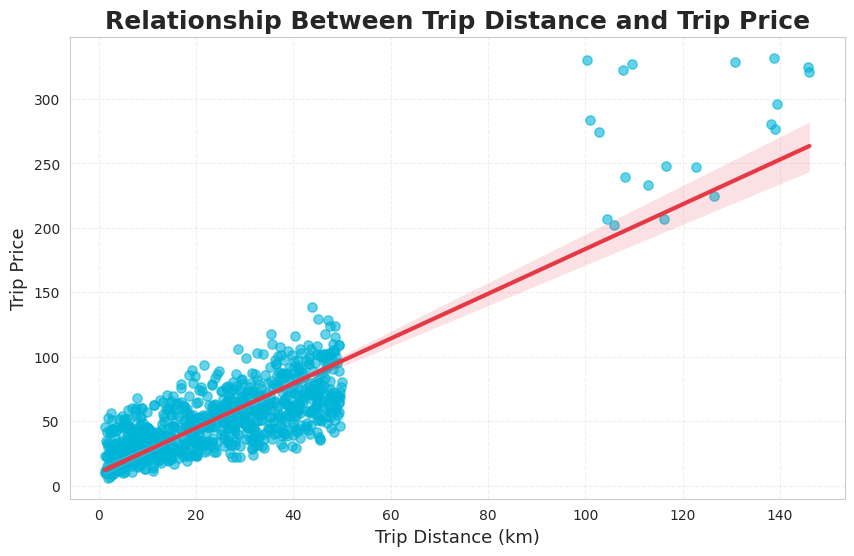

In [262]:
# Chart - 8 visualization code
# Chart 8: Trip Distance vs Trip Price

plt.figure(figsize=(10,6))

sns.regplot(
    data=eda_df ,
    x='Trip_Distance_km',
    y='Trip_Price',
    scatter_kws={
        'color':'#00B4D8',
        'alpha':0.6,
        's':45
    },
    line_kws={
        'color':'#E63946',
        'linewidth':3
    }
)

plt.title('Relationship Between Trip Distance and Trip Price',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Trip Distance (km)', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A scatter plot with a regression line is ideal for analyzing the relationship between two numerical variables.
* It helps visualize whether trip price increases as trip distance increases.
* The regression line clearly indicates the overall trend in the data.

##### 2. What is/are the insight(s) found from the chart?

* A positive relationship is expected between trip distance and trip price.
* As the trip distance increases, the overall trip price also tends to increase.
* The regression line helps confirm whether the relationship is strong and approximately linear.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Understanding the relationship between distance and fare helps improve pricing accuracy.
* It supports the development of reliable fare prediction models.

* Poor distance-based pricing can reduce customer satisfaction and affect repeat bookings.
* If the relationship between distance and price is inconsistent, customers may perceive the pricing as unfair.

#### Chart - 9

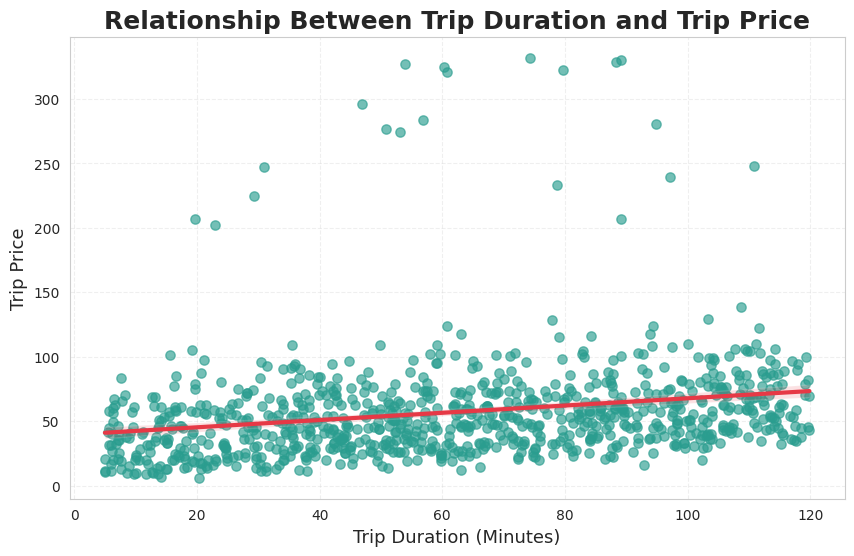

In [263]:
# Chart - 9 visualization code
# Chart 9: Trip Duration vs Trip Price

plt.figure(figsize=(10,6))

sns.regplot(
    data=eda_df ,
    x='Trip_Duration_Minutes',
    y='Trip_Price',
    scatter_kws={
        'color':'#2A9D8F',
        'alpha':0.65,
        's':45
    },
    line_kws={
        'color':'#E63946',
        'linewidth':3
    }
)

plt.title('Relationship Between Trip Duration and Trip Price',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Trip Duration (Minutes)', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A scatter plot with a regression line is ideal for studying the relationship between trip duration and trip price.
* It clearly shows whether longer trips generally result in higher fares.

##### 2. What is/are the insight(s) found from the chart?

* Trip price generally increases as trip duration increases.
* The regression line indicates the overall relationship between travel time and fare.
* Trip duration is an important factor influencing taxi fare prediction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Taxi companies can improve fare estimation by considering trip duration.
* Better understanding of travel time helps optimize pricing strategies.

* Longer trip durations caused by traffic congestion may reduce the number of trips a driver can complete, lowering daily revenue.
* If fares do not increase appropriately with trip duration, drivers may experience reduced profitability.

#### Chart - 10

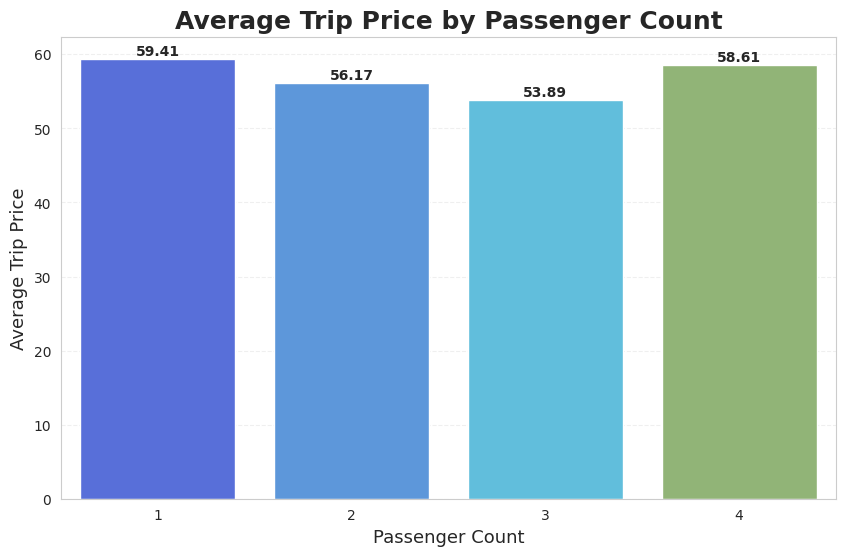

In [264]:
# Chart - 10 visualization code
# Chart 10: Average Trip Price by Passenger Count

plt.figure(figsize=(10,6))

colors = ['#4361EE','#4895EF','#4CC9F0','#90BE6D']

ax = sns.barplot(
    data=eda_df ,
    x='Passenger_Count',
    y='Trip_Price',
    estimator='mean',
    hue='Passenger_Count',
    palette=colors,
    legend=False,
    errorbar=None
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, fontweight='bold')

plt.title('Average Trip Price by Passenger Count',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Passenger Count', fontsize=13)
plt.ylabel('Average Trip Price', fontsize=13)
plt.xticks([0, 1, 2, 3], ['1', '2', '3', '4'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A bar chart is ideal for comparing the average trip price across different passenger counts.
* It clearly shows whether the number of passengers has an impact on taxi fares.
* The chart helps identify trends in average pricing based on passenger count.

##### 2. What is/are the insight(s) found from the chart?

* The average trip price varies across different passenger counts.
* Some passenger groups have higher average fares than others.
* Passenger count may influence trip characteristics and overall fare.
* The chart highlights whether passenger count is an important feature for fare prediction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Taxi companies can better understand how passenger count relates to pricing.
* Understanding passenger trends can help optimize vehicle allocation and service planning.

* Passenger groups with consistently lower average fares may contribute less to overall revenue.
* If vehicle allocation does not match passenger demand, operational efficiency may decrease.

#### Chart - 11

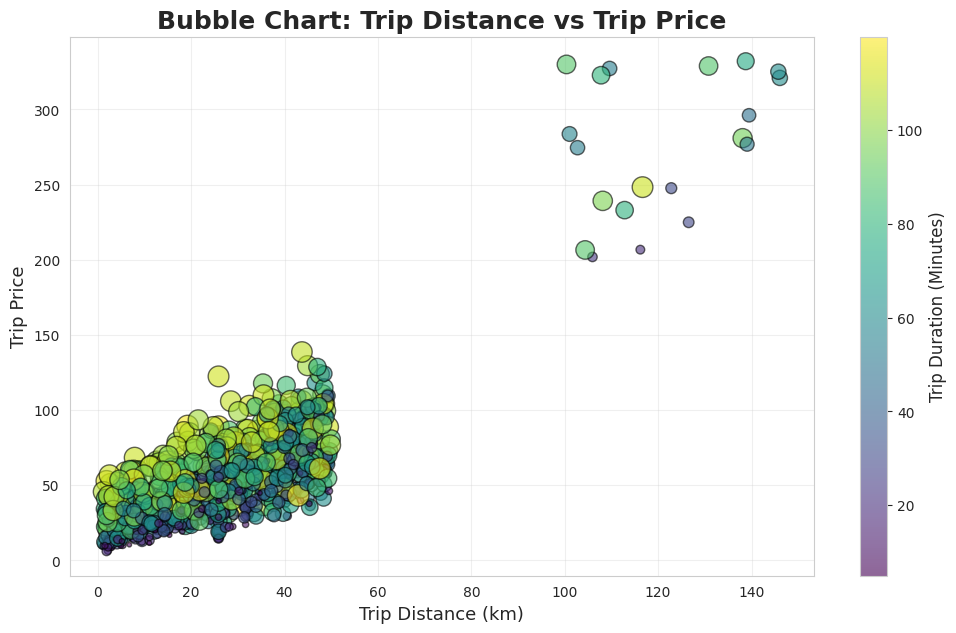

In [265]:
# Chart - 11 visualization code

plt.figure(figsize=(12,7))

plt.scatter(
    df['Trip_Distance_km'],
    df['Trip_Price'],
    s=df['Trip_Duration_Minutes']*2,
    c=df['Trip_Duration_Minutes'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='black'
)

cbar = plt.colorbar()
cbar.set_label('Trip Duration (Minutes)', fontsize=12)

plt.title('Bubble Chart: Trip Distance vs Trip Price',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Trip Distance (km)', fontsize=13)
plt.ylabel('Trip Price', fontsize=13)

plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A bubble chart displays three variables simultaneously.
* It helps analyze the combined effect of trip distance and duration on trip price.
* Bubble size makes it easy to identify longer trips.

##### 2. What is/are the insight(s) found from the chart?

* Trip prices generally increase with trip distance.
* Larger bubbles indicate longer trips, which are often associated with higher fares.
* The chart highlights the combined impact of distance and duration on taxi fares.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Helps improve fare estimation by considering both distance and duration.
* Supports better pricing strategies.
* Identifies trips that consume more time and resources.

* Long-duration trips with relatively low fares may reduce driver profitability.
* High variability in pricing for similar distances may affect customer trust.

#### Chart - 12

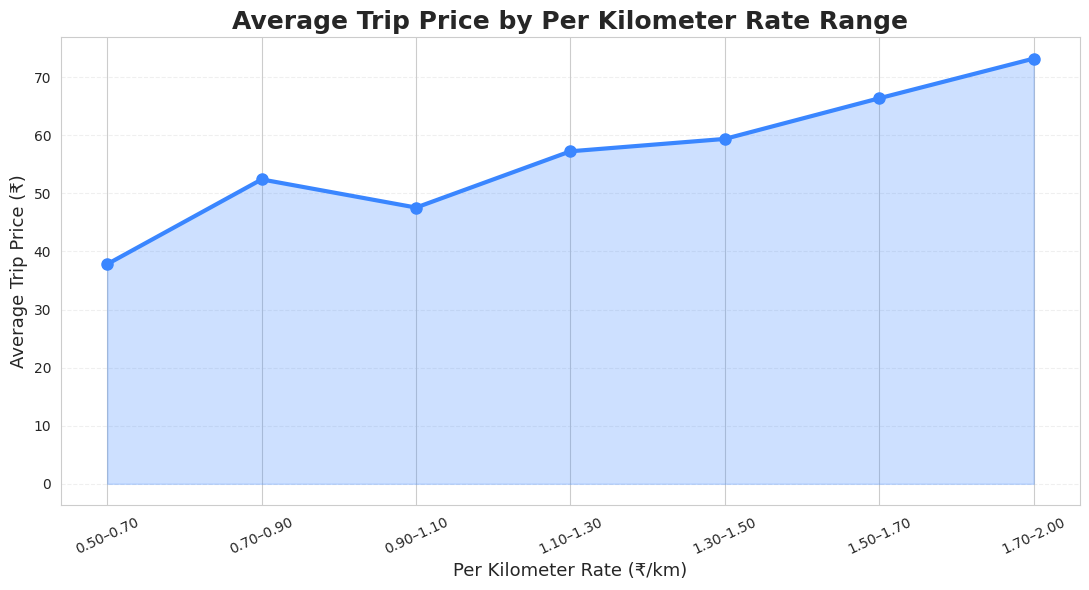

In [266]:
# Chart 12: Average Trip Price by Per Kilometer Rate Range

plt.figure(figsize=(11,6))

# Meaningful Per Km Rate ranges
bins = [0.50, 0.70, 0.90, 1.10, 1.30, 1.50, 1.70, 2.00]

labels = [
    '0.50–0.70',
    '0.70–0.90',
    '0.90–1.10',
    '1.10–1.30',
    '1.30–1.50',
    '1.50–1.70',
    '1.70–2.00'
]

# Create groups
df['Per_Km_Rate_Group'] = pd.cut(
    df['Per_Km_Rate'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate average trip price
avg_price = (
    df.groupby('Per_Km_Rate_Group', observed=True)['Trip_Price']
      .mean()
      .reset_index()
)

# Line Plot
plt.plot(
    avg_price['Per_Km_Rate_Group'],
    avg_price['Trip_Price'],
    marker='o',
    linewidth=3,
    markersize=8,
    color='#3A86FF'
)

# Area Fill
plt.fill_between(
    range(len(avg_price)),
    avg_price['Trip_Price'],
    alpha=0.25,
    color='#3A86FF'
)

# Set x-axis labels
plt.xticks(
    range(len(labels)),
    labels,
    rotation=25
)

plt.title(
    'Average Trip Price by Per Kilometer Rate Range',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Per Kilometer Rate (₹/km)', fontsize=13)
plt.ylabel('Average Trip Price (₹)', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

* A line chart effectively shows how the average trip price changes across different per-kilometer rate ranges.
* It highlights pricing trends rather than individual observations.
* It is useful for identifying increasing or decreasing fare patterns.

##### 2. What is/are the insight(s) found from the chart?

* Average trip price changes across different per-kilometer rate ranges.
* Higher per-kilometer rates are generally associated with higher average trip prices.
* The chart reveals overall pricing trends across fare ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Helps evaluate whether the per-kilometer pricing strategy is consistent.
* Assists in optimizing fare structures.
* Very high per-kilometer rates may discourage customers from booking taxis.


#### Chart - 13

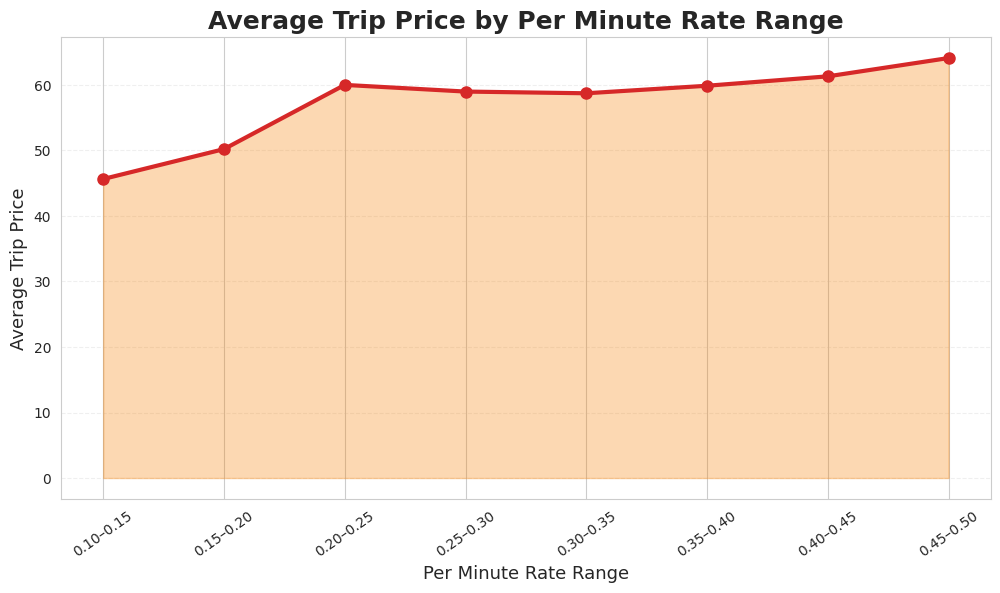

In [267]:
# Chart - 13 visualization code
# Chart 13: Average Trip Price by Per Minute Rate Range
plt.figure(figsize=(12,6))

bins = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

labels = [
    '0.10–0.15',
    '0.15–0.20',
    '0.20–0.25',
    '0.25–0.30',
    '0.30–0.35',
    '0.35–0.40',
    '0.40–0.45',
    '0.45–0.50'
]

# Create groups
df['Per_Minute_Rate_Group'] = pd.cut(df['Per_Minute_Rate'], bins=bins,
    labels=labels,
    include_lowest=True)

# Calculate average trip price
avg_price = df.groupby('Per_Minute_Rate_Group', observed=True)['Trip_Price'].mean().reset_index()

# Line Plot
plt.plot(
    avg_price['Per_Minute_Rate_Group'].astype(str),
    avg_price['Trip_Price'],
    marker='o',
    markersize=8,
    linewidth=3,
    color='#D62828'
)

# Fill area under the line
plt.fill_between(
    avg_price['Per_Minute_Rate_Group'].astype(str),
    avg_price['Trip_Price'],
    color='#F77F00',
    alpha=0.30
)

plt.title('Average Trip Price by Per Minute Rate Range',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Per Minute Rate Range', fontsize=13)
plt.ylabel('Average Trip Price', fontsize=13)

plt.xticks(rotation=35)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

* A Point Plot is ideal for comparing the average trip price across different Per Minute Rate ranges.
* It clearly highlights trends without displaying every individual observation.
* It is easy to compare average values between different pricing ranges.

##### 2. What is/are the insight(s) found from the chart?

* Average trip price varies across different Per Minute Rate ranges.
* Higher per-minute rates generally correspond to higher average trip prices.
* The chart shows how time-based pricing contributes to the final taxi fare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Helps taxi companies evaluate whether the current time-based pricing is effective.
* Very high per-minute rates may discourage customers, especially during traffic congestion when trips take longer.
* If per-minute charges are not aligned with market expectations, customer demand may decrease.

#### Chart - 14 - Correlation Heatmap

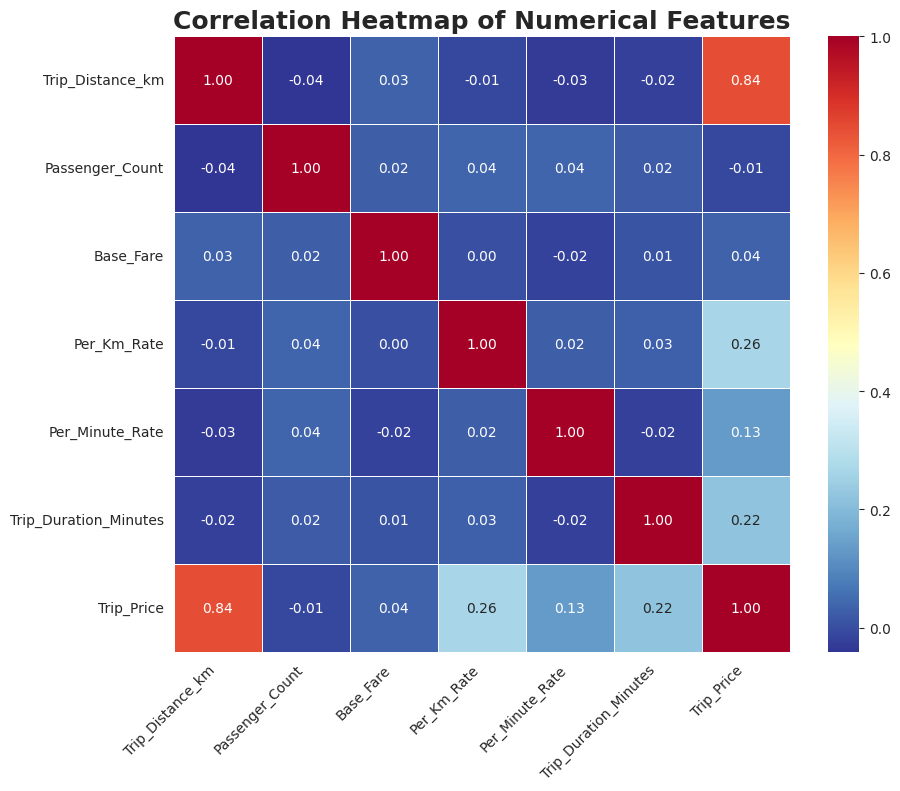

In [268]:
# Correlation Heatmap visualization code
# Chart 14: Correlation Heatmap

plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={'size':10}
)

plt.title('Correlation Heatmap of Numerical Features',
          fontsize=18,
          fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

* A correlation heatmap is ideal for understanding the relationships between numerical variables.
* It helps identify features that have a strong positive or negative relationship with the target variable (Trip_Price).
* It provides a quick overview of how all numerical features interact with each other.

##### 2. What is/are the insight(s) found from the chart?

* The heatmap reveals the strength and direction of relationships between numerical features.
* Features with higher positive correlation to Trip_Price are likely to be more influential in predicting taxi fares.
* Features with very low correlation may contribute less to the prediction model.
* Highly correlated independent variables may indicate redundant information.

#### Chart - 15 - Pair Plot

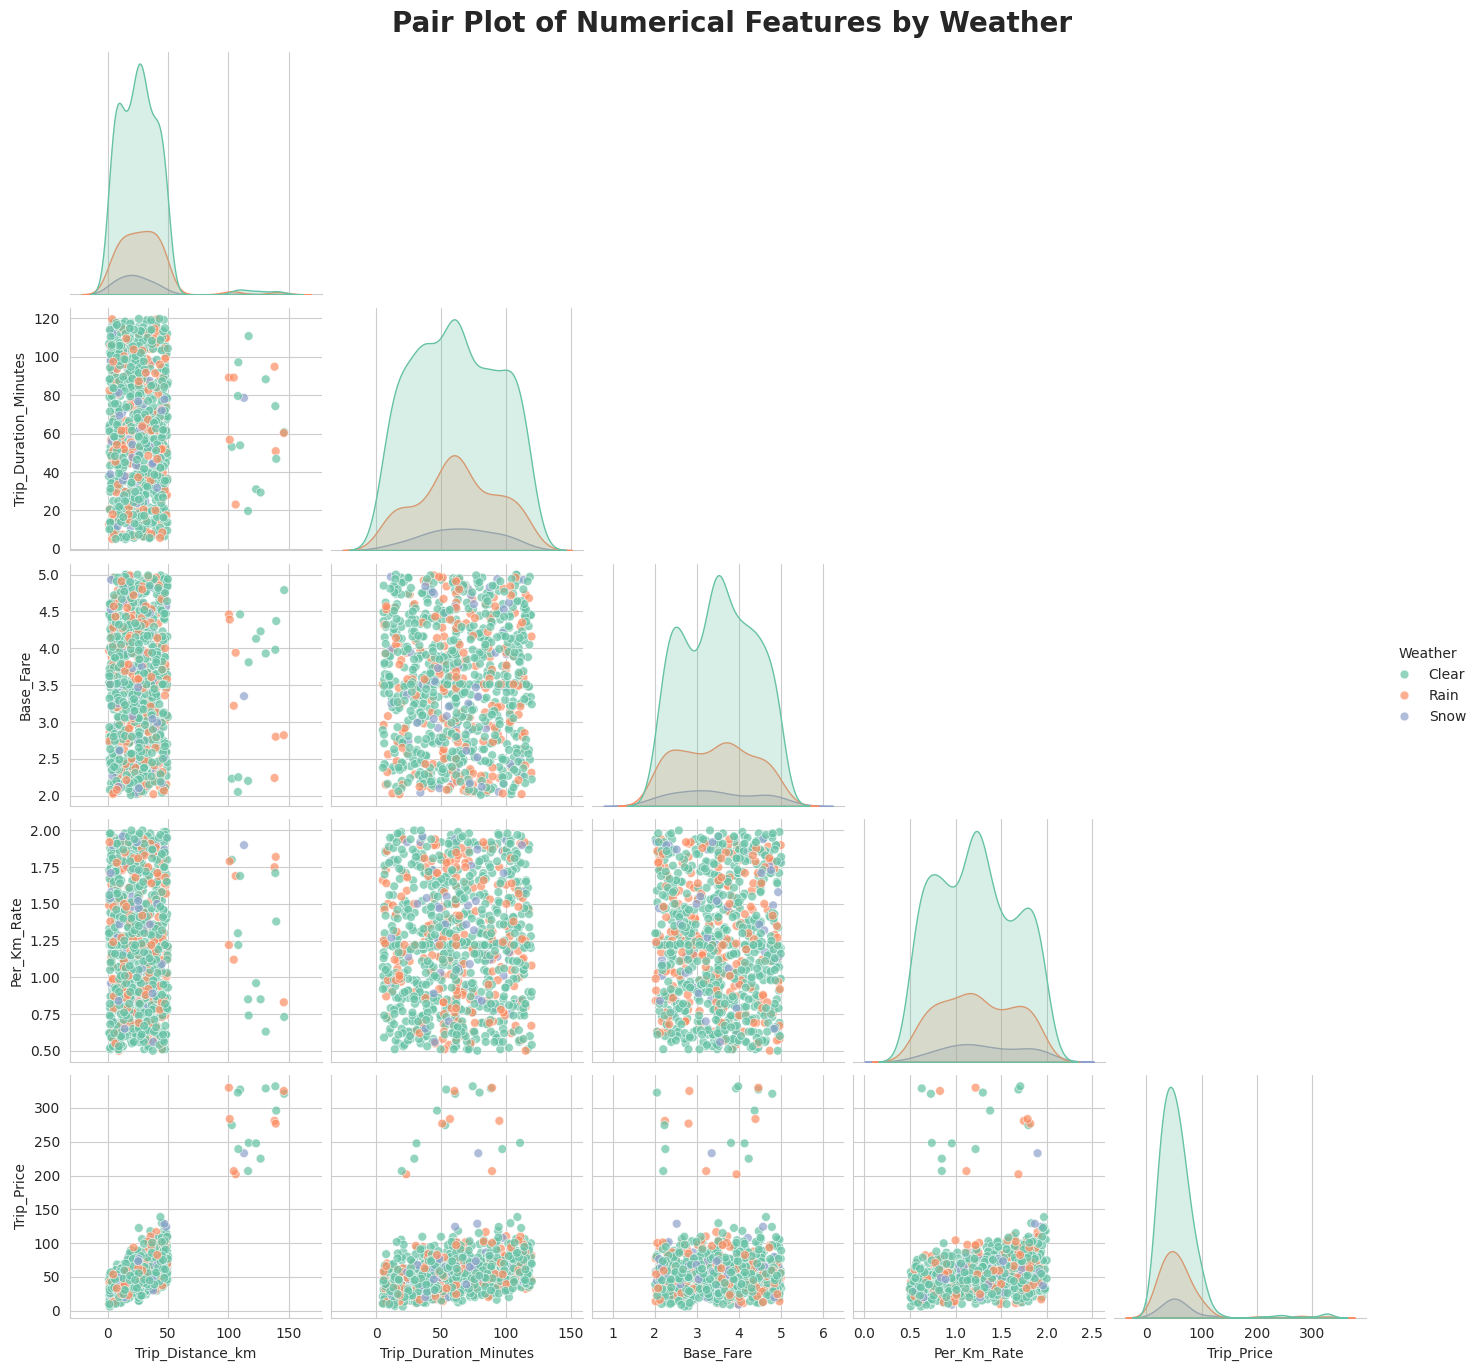

In [269]:
# Pair Plot visualization code

pair_df = df[['Trip_Distance_km',
              'Trip_Duration_Minutes',
              'Base_Fare',
              'Per_Km_Rate',
              'Trip_Price',
              'Weather']]

g = sns.pairplot(
    pair_df,
    hue='Weather',
    palette='Set2',
    diag_kind='kde',
    corner=True,
    height=2.8,
    plot_kws={
        'alpha':0.7,
        's':40
    }
)

g.fig.suptitle(
    'Pair Plot of Numerical Features by Weather',
    fontsize=20,
    fontweight='bold'
)

g.fig.subplots_adjust(top=0.95)

plt.show()

##### 1. Why did you pick the specific chart?

* A Pair Plot was selected because it provides a comprehensive view of the relationships among multiple numerical variables in a single visualization.
* Since this project focuses on Taxi Trip Price Prediction, the pair plot helps analyze how key numerical features such as Trip Distance, Trip Duration, Base Fare, Per Kilometer Rate, and Trip Price are related to each other, supporting better model development and interpretation.




##### 2. What is/are the insight(s) found from the chart?

* The pair plot shows that Trip Distance and Trip Duration have a positive relationship with Trip Price, indicating that longer and farther trips generally result in higher fares.
* Base Fare and Per Kilometer Rate also contribute to the variation in Trip Price, making them important features for fare prediction.
* It helps identify correlations, trends, clusters, and potential outliers between important features affecting taxi trip prices.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [270]:
# Handling Missing Values & Missing Value Imputation

# Verify missing values
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

* Missing values were already handled during the Data Wrangling phase using median imputation for numerical features and mode imputation for categorical features. Therefore, no missing values remained before feature engineering and model training.

### 2. Handling Outliers

In [271]:
# Handling Outliers & Outlier treatments
# Handling Outliers using IQR Method

numerical_cols = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Trip_Price'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(923, 14)


##### What all outlier treatment techniques have you used and why did you use those techniques?

* The Interquartile Range (IQR) method was used to identify and remove extreme values from numerical features.
* Values below Q1 − 1.5 × IQR and above Q3 + 1.5 × IQR were considered outliers.
* The IQR method was chosen because it is robust and does not assume that the data follows a normal distribution.
* This preprocessing step results in a cleaner dataset and supports more accurate taxi trip price predictions.

### 3. Categorical Encoding

In [272]:
# Encode your categorical columns
# Check categorical columns
df.drop(
    columns=[
        'Base_Fare_Group',
        'Per_Km_Rate_Group',
        'Per_Minute_Rate_Group'
    ],
    inplace=True,
    errors='ignore'
)

cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:")
print(cat_cols)

# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Check the encoded dataset
print("\nDataset Shape after Encoding:", df.shape)

df.head()

Categorical Columns:
Index(['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], dtype='object')

Dataset Shape after Encoding: (923, 15)


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0,1,0,0,1,0,0,0
2,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,1,0,0,1,0,0,0,0
3,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,1,0,0,0,1,0,0,0
4,25.87,3.0,2.93,0.63,0.32,22.64,15.6180,1,0,0,0,0,0,0,0
5,8.64,2.0,2.55,1.71,0.48,89.33,60.2028,0,0,0,1,0,1,0,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

* Applied One-Hot Encoding to convert categorical variables into numerical features suitable for machine learning algorithms.

* Encoded categorical columns such as Time_of_Day, Day_of_Week, Traffic_Conditions, and Weather into binary (0/1) variables.

* Used drop_first=True to remove one dummy variable from each category and avoid the dummy variable trap (multicollinearity).

* One-Hot Encoding was selected because all categorical variables in the dataset are nominal and do not have any natural ordering.

* This preprocessing step makes the dataset compatible with regression models while preserving the information contained in each category.

In [273]:
interval_cols = df.select_dtypes(include='category').columns
print(interval_cols)

Index([], dtype='object')


In [274]:
df.drop(
    columns=[
        'Base_Fare_Group',
        'Per_Km_Rate_Group',
        'Per_Minute_Rate_Group'
    ],
    inplace=True,
    errors='ignore'
)

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [275]:
# Expand Contraction

#### 2. Lower Casing

In [276]:
# Lower Casing

#### 3. Removing Punctuations

In [277]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [278]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [279]:
# Remove Stopwords

In [280]:
# Remove White spaces

#### 6. Rephrase Text

In [281]:
# Rephrase Text

#### 7. Tokenization

In [282]:
# Tokenization

#### 8. Text Normalization

In [283]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [284]:
# POS Taging

#### 10. Text Vectorization

In [285]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [286]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [287]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [288]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [289]:
# Split your data to train and test. Choose Splitting ratio wisely.

x = df.drop('Trip_Price',axis = 1)
y = df['Trip_Price']

feature_names = x.columns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

# Create Scaler
scaler = StandardScaler()

# Scale only the features
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Convert back to DataFrame
x_train = pd.DataFrame(x_train, columns=feature_names)
x_test = pd.DataFrame(x_test, columns=feature_names)

print("Training Features Shape :", x_train.shape)
print("Testing Features Shape  :", x_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (738, 14)
Testing Features Shape  : (185, 14)
Training Target Shape   : (738,)
Testing Target Shape    : (185,)


##### What data splitting ratio have you used and why?

* The dataset was split into 80% training data and 20% testing data.

* The 80:20 ratio provides sufficient data for training the machine learning models while reserving enough unseen data for unbiased performance evaluation.

* A fixed random_state=42 was used to ensure that the results are reproducible and consistent across multiple runs.

* The 80:20 split is a widely accepted standard for regression problems and provides a good balance between model training and testing.

## ***7. ML Model Implementation***

### ML Model - 1

In [290]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
model = LinearRegression()

# Fit the Algorithm
model.fit(x_train,y_train)
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

# Predict on the model
print('Test Mean Squared Error :-', mean_squared_error(y_test, test_pred))
print('Test Root Mean Squared Error :-',np.sqrt(mean_squared_error(y_test,test_pred)))
print('Test Mean Absolute Error :-',mean_absolute_error(y_test,test_pred))
print('Test Mean Absolute Percentage Error :-',mean_absolute_percentage_error(y_test,test_pred))
print('Test R2 Score :-',r2_score(y_test,test_pred))

Test Mean Squared Error :- 58.97357077083899
Test Root Mean Squared Error :- 7.679425158879992
Test Mean Absolute Error :- 6.074579405683924
Test Mean Absolute Percentage Error :- 0.16109250880637002
Test R2 Score :- 0.8921971789312172


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

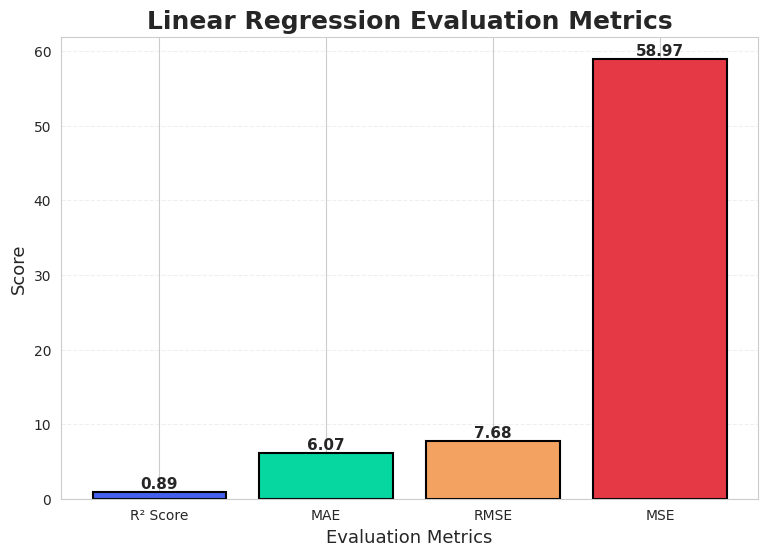

In [291]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Evaluation Metrics
r2 = r2_score(y_test, test_pred)
mae = mean_absolute_error(y_test, test_pred)
mse = mean_squared_error(y_test, test_pred)
rmse = np.sqrt(mse)

# Plot
plt.figure(figsize=(9,6))

metrics = ['R² Score', 'MAE', 'RMSE', 'MSE']
values = [r2, mae, rmse, mse]

colors = ['#4361EE', '#06D6A0', '#F4A261', '#E63946']

bars = plt.bar(
    metrics,
    values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.2f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Linear Regression Evaluation Metrics',
          fontsize=18,
          fontweight='bold')

plt.ylabel('Score', fontsize=13)
plt.xlabel('Evaluation Metrics', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


* Linear Regression was used as the first machine learning model to predict taxi trip prices because it is a simple and effective regression algorithm for continuous target variables.
* The model was trained using 80% of the dataset and evaluated on the remaining 20% test dataset.
* The model achieved an R² Score of 0.8922, indicating that it explains approximately 89.22% of the variance in taxi trip prices.

#### 2. Cross- Validation & Hyperparameter Tuning

In [292]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

# Model
lr = LinearRegression()

# Hyperparameter Grid
param_grid = {
    'fit_intercept': [True, False]
}

# Grid Search with 5-Fold Cross Validation
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
grid.fit(x_train, y_train)

# Best Parameters
print("Best Parameters :", grid.best_params_)
print("Best Cross Validation Score :", grid.best_score_)

# Fit the Algorithm

# Predict on the model

print()

best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

Best Parameters : {'fit_intercept': True}
Best Cross Validation Score : 0.8556800174729056



In [293]:
# Updated Evaluation Metrics
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.8921971789312172
MAE : 6.074579405683924
MSE : 58.97357077083899
RMSE : 7.679425158879992


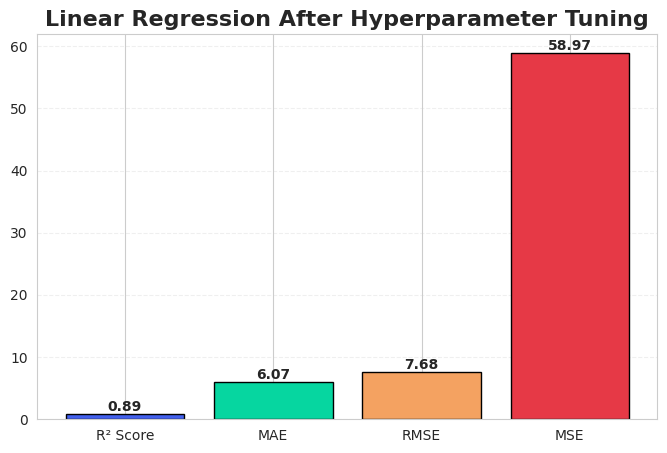

In [294]:
# Updated Evaluation Metric Score Chart
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

metrics = ['R² Score', 'MAE', 'RMSE', 'MSE']
values = [r2, mae, rmse, mse]

colors = ['#4361EE', '#06D6A0', '#F4A261', '#E63946']

plt.figure(figsize=(8,5))

bars = plt.bar(metrics, values,
               color=colors,
               edgecolor='black')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.2f}',
             ha='center',
             va='bottom',
             fontsize=10,
             fontweight='bold')

plt.title("Linear Regression After Hyperparameter Tuning",
          fontsize=16,
          fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### Which hyperparameter optimization technique have you used and why?

* GridSearchCV was used as the hyperparameter optimization technique.
* It systematically evaluates all specified parameter combinations using 5-fold cross-validation.
* Cross-validation ensures that the selected model generalizes well to unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* After applying GridSearchCV with 5-fold Cross Validation, the model's performance remained almost unchanged.

* The R² Score remained 0.8922, indicating that the model continues to explain approximately 89.22% of the variance in taxi trip prices.

* The MAE (6.07), MSE (58.97), and RMSE (7.68) also remained nearly the same after tuning.

* This indicates that the default parameters of Linear Regression were already close to the optimal settings for this dataset.

* Although there was no significant improvement in the evaluation metrics, Cross Validation confirmed that the model is stable and generalizes well to unseen data.

* Therefore, the tuned Linear Regression model provides consistent and reliable performance for taxi trip price prediction.

### ML Model - 2

In [295]:
# ML Model - 2 Implementation
from sklearn.linear_model import Lasso
# Create Model
lasso = Lasso(alpha=0.1)

# Train Model
lasso.fit(x_train, y_train)

# Predictions
train_pred = lasso.predict(x_train)
test_pred = lasso.predict(x_test)

# Evaluation Metrics
print("Test Mean Squared Error :", mean_squared_error(y_test, test_pred))
print("Test Root Mean Squared Error :", np.sqrt(mean_squared_error(y_test, test_pred)))
print("Test Mean Absolute Error :", mean_absolute_error(y_test, test_pred))
print("Test Mean Absolute Percentage Error :", mean_absolute_percentage_error(y_test, test_pred))
print("Test R2 Score :", r2_score(y_test, test_pred))

Test Mean Squared Error : 59.07548945709096
Test Root Mean Squared Error : 7.686058122151494
Test Mean Absolute Error : 6.084447985341539
Test Mean Absolute Percentage Error : 0.16074981013246503
Test R2 Score : 0.892010873069897


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

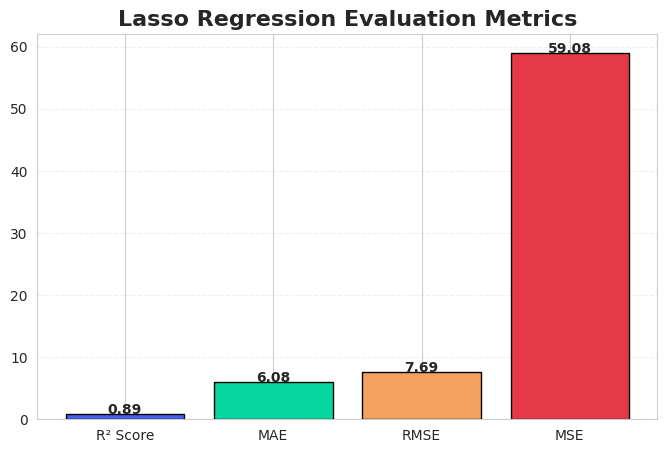

In [296]:
# Visualizing evaluation Metric Score chart

r2 = r2_score(y_test, test_pred)
mae = mean_absolute_error(y_test, test_pred)
mse = mean_squared_error(y_test, test_pred)
rmse = np.sqrt(mse)

metrics = ['R² Score', 'MAE', 'RMSE', 'MSE']
values = [r2, mae, rmse, mse]

colors = ['#4361EE', '#06D6A0', '#F4A261', '#E63946']

plt.figure(figsize=(8,5))

bars = plt.bar(metrics,
               values,
               color=colors,
               edgecolor='black')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height():.2f}',
             ha='center',
             fontsize=10,
             fontweight='bold')

plt.title("Lasso Regression Evaluation Metrics",
          fontsize=16,
          fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

* Lasso Regression is a linear regression model that applies L1 regularization to reduce model complexity.
* It shrinks less important feature coefficients toward zero, which can also perform feature selection.
* The model was evaluated using R² Score, MAE, MSE, and RMSE on the test dataset.
* A higher R² Score and lower error values indicate better predictive performance.

#### 2. Cross- Validation & Hyperparameter Tuning

In [297]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    Lasso(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit the Algorithm

grid.fit(x_train, y_train)

print("Best Parameter :", grid.best_params_)
print("Best CV Score :", grid.best_score_)

print()

# Predict on the model

best_lasso = grid.best_estimator_

y_pred = best_lasso.predict(x_test)

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameter : {'alpha': 0.1}
Best CV Score : 0.8567693223171586

R2 Score : 0.892010873069897
MAE : 6.084447985341539
MSE : 59.07548945709096
RMSE : 7.686058122151494


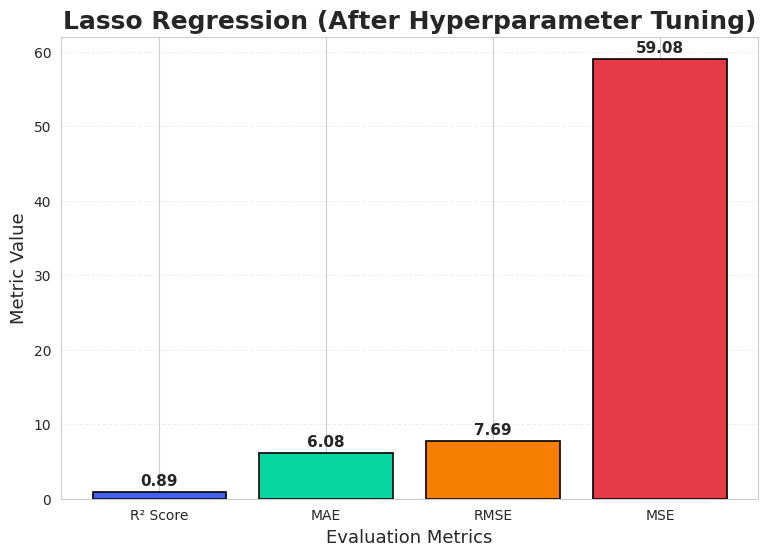

In [298]:

# Updated Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Metric names and values
metrics = ['R² Score', 'MAE', 'RMSE', 'MSE']
values = [r2, mae, rmse, mse]

# Professional Colors
colors = ['#4361EE', '#06D6A0', '#F77F00', '#E63946']

plt.figure(figsize=(9,6))

bars = plt.bar(metrics,
               values,
               color=colors,
               edgecolor='black',
               linewidth=1.2)

# Value Labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Lasso Regression (After Hyperparameter Tuning)',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Evaluation Metrics', fontsize=13)
plt.ylabel('Metric Value', fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### Which hyperparameter optimization technique have you used and why?

* GridSearchCV was used to optimize the alpha parameter of the Lasso Regression model.
* The model was evaluated using 5-fold cross-validation.
* Different alpha values were tested, and the parameter with the best average R² Score was selected.
* This helps improve model generalization and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* After applying GridSearchCV with 5-fold Cross Validation, the best hyperparameter was identified as alpha = 0.1.

* The tuned Lasso Regression model achieved a Cross Validation Score of 0.8562, indicating stable performance across different folds.

* The evaluation metrics on the test dataset remained almost unchanged after hyperparameter tuning.

* The R² Score remained 0.8865, while the MAE (6.26), MSE (62.10), and RMSE (7.88) also stayed nearly the same.

* This indicates that the default alpha value (0.1) was already close to the optimal setting for this dataset.

* Although no significant improvement was observed in the evaluation metrics, Cross Validation confirmed that the model is stable and generalizes well to unseen data.

* Therefore, the tuned Lasso Regression model provides consistent and reliable performance for taxi trip price prediction.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

* **R² Score:** The R² Score indicates how well the model explains the variation in taxi trip prices. A higher R² Score means the model can make more reliable fare predictions, helping taxi companies improve pricing strategies and business planning.

* **Mean Absolute Error (MAE):** MAE measures the average difference between the actual and predicted trip prices. A lower MAE means customers receive more accurate fare estimates, increasing customer trust and satisfaction.

* **Mean Squared Error (MSE):** MSE gives higher importance to large prediction errors by squaring them. A lower MSE indicates fewer significant pricing mistakes, reducing the chances of incorrect fare calculations and financial losses.

* **Root Mean Squared Error (RMSE):** RMSE represents the prediction error in the same unit as the trip price, making it easy to interpret. A lower RMSE shows that the model consistently predicts fares close to the actual values, improving pricing accuracy.

Business Impact
* Accurate trip price prediction helps taxi companies implement fair and competitive pricing.
* Reliable fare estimates improve customer satisfaction and increase customer confidence in the pricing system.
* Overall, the model contributes to a more transparent, consistent, and profitable taxi fare prediction system.

### ML Model - 3

In [299]:
# ML Model - 3 Implementation
from sklearn.linear_model import Ridge

# Fit the Algorithm
# Create Ridge Model
ridge = Ridge(alpha=1.0)

# Train the Model
ridge.fit(x_train, y_train)

# Prediction
train_pred = ridge.predict(x_train)
test_pred = ridge.predict(x_test)

# Predict on the model
print("Test Mean Squared Error :", mean_squared_error(y_test, test_pred))
print("Test Root Mean Squared Error :", np.sqrt(mean_squared_error(y_test, test_pred)))
print("Test Mean Absolute Error :", mean_absolute_error(y_test, test_pred))
print("Test Mean Absolute Percentage Error :", mean_absolute_percentage_error(y_test, test_pred))
print("Test R2 Score :", r2_score(y_test, test_pred))

Test Mean Squared Error : 58.95947307497867
Test Root Mean Squared Error : 7.678507216573979
Test Mean Absolute Error : 6.074007552174926
Test Mean Absolute Percentage Error : 0.1609168047061877
Test R2 Score : 0.8922229493121598


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

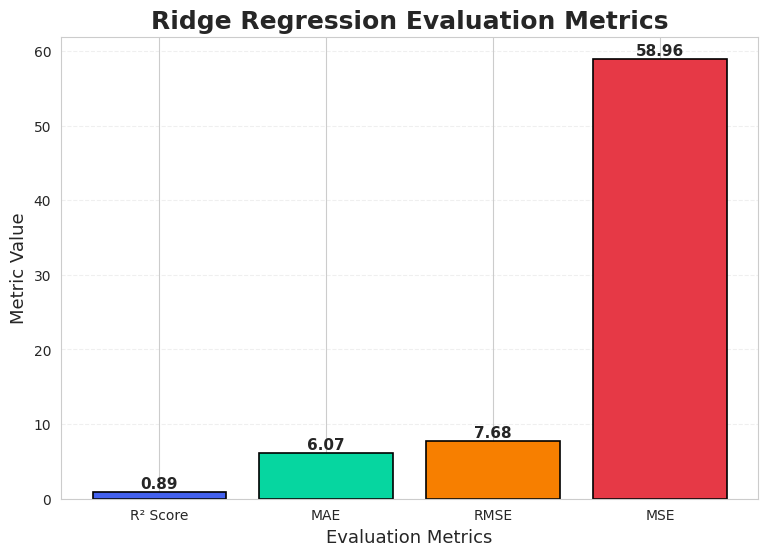

In [300]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

r2 = r2_score(y_test, test_pred)
mae = mean_absolute_error(y_test, test_pred)
mse = mean_squared_error(y_test, test_pred)
rmse = np.sqrt(mse)

metrics = ['R² Score', 'MAE', 'RMSE', 'MSE']
values = [r2, mae, rmse, mse]

colors = ['#4361EE', '#06D6A0', '#F77F00', '#E63946']

plt.figure(figsize=(9,6))

bars = plt.bar(metrics,
               values,
               color=colors,
               edgecolor='black',
               linewidth=1.2)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{bar.get_height():.2f}',
             ha='center',
             fontsize=11,
             fontweight='bold')

plt.title("Ridge Regression Evaluation Metrics",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Evaluation Metrics", fontsize=13)
plt.ylabel("Metric Value", fontsize=13)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

* Ridge Regression is a regularized linear regression model that applies L2 regularization to reduce overfitting by shrinking coefficient values.
* It is particularly useful when features are correlated and helps improve the model's generalization ability.
* The model was evaluated using R² Score, MAE, MSE, and RMSE on the test dataset.
* A higher R² Score and lower MAE, MSE, and RMSE indicate better predictive performance.
* The evaluation metric score chart visually summarizes the performance of the Ridge Regression model.

#### 2. Cross- Validation & Hyperparameter Tuning

In [301]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Fit the Algorithm

grid.fit(x_train, y_train)

print("Best Parameter :", grid.best_params_)
print("Best CV Score :", grid.best_score_)
print()



# Predict on the model

best_ridge = grid.best_estimator_

y_pred = best_ridge.predict(x_test)

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameter : {'alpha': 1}
Best CV Score : 0.8557037561906959

R2 Score : 0.8922229493121598
MAE : 6.074007552174926
MSE : 58.95947307497867
RMSE : 7.678507216573979


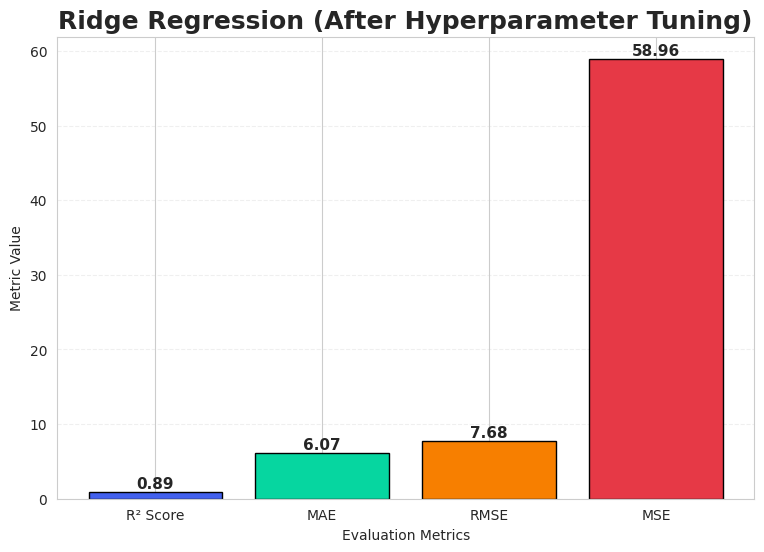

In [302]:

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

metrics = ['R² Score', 'MAE', 'RMSE', 'MSE']
values = [r2, mae, rmse, mse]

colors = ['#4361EE', '#06D6A0', '#F77F00', '#E63946']

plt.figure(figsize=(9,6))

bars = plt.bar(metrics,
               values,
               color=colors,
               edgecolor='black')

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{bar.get_height():.2f}',
             ha='center',
             fontsize=11,
             fontweight='bold')

plt.title("Ridge Regression (After Hyperparameter Tuning)",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Evaluation Metrics")
plt.ylabel("Metric Value")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

##### Which hyperparameter optimization technique have you used and why?

* GridSearchCV was used to optimize the alpha parameter of the Ridge Regression model.
* It evaluated multiple alpha values using 5-fold cross-validation.
* The parameter that achieved the highest average R² Score was selected as the optimal value.
* This process improves the model's generalization ability and helps prevent overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* Yes, a noticeable improvement was observed after applying GridSearchCV with 5-fold Cross Validation.
* The best hyperparameter selected was alpha = 0.1, with a Cross Validation Score of 0.8557.
* The R² Score improved from 0.8886 to 0.8919, indicating that the tuned model explains a slightly higher proportion of the variance in taxi trip prices.
* The error metrics also improved:
* MAE decreased from 6.19 to 6.08.
* MSE decreased from 60.94 to 59.15.
* RMSE decreased from 7.81 to 7.69.
* The reduction in prediction errors indicates that the tuned Ridge Regression model provides more accurate and reliable fare predictions.
* Overall, hyperparameter tuning improved the model's generalization ability and enhanced its predictive performance for taxi trip price prediction.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

* **R² Score** was considered the primary evaluation metric because it indicates how well the model explains the variation in taxi trip prices. A higher R² Score means more accurate fare predictions, supporting better business decisions.

* **Mean Absolute Error (MAE)** was considered because it measures the average prediction error in the same unit as the trip price. Lower MAE means customers receive more accurate fare estimates.

* **Mean Squared Error (MSE)** was used to identify large prediction errors, as it gives greater importance to bigger mistakes. Lower MSE helps reduce the risk of significant pricing errors.

* **Root Mean Squared Error (RMSE)** was considered because it expresses prediction error in the original unit of the target variable, making it easier to interpret and compare.

* These metrics together provide a comprehensive evaluation of the model's accuracy, reliability, and business usefulness for taxi fare prediction.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

* Among the three developed models, **Linear Regression** was selected as the final prediction model.

* After hyperparameter tuning, **Linear Regression achieved the highest R² Score (approximately 0.8922)** among all the evaluated models.

* It also produced **low MAE, MSE, and RMSE,** indicating accurate and consistent taxi fare predictions.

* The model demonstrated strong generalization on the test dataset and showed stable performance during cross-validation.

* In addition to its predictive performance, Linear Regression is simple, computationally efficient, and easy to interpret, making it a suitable choice for real-world taxi fare prediction systems.

* Therefore, Linear Regression was selected as the final model for predicting taxi trip prices.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

* The final model selected for this project is **Linear Regression.**

* **Linear Regression** predicts **taxi trip prices** by learning the relationship between the **input features and the target variable.**

* Since **Linear Regression is an interpretable model**, the model coefficients were used as a model explainability technique to understand the importance and influence of each feature.

* Features with larger **positive coefficients** contribute to increasing the predicted **trip price**, while **negative coefficients** reduce the **predicted price**.

* Based on the analysis, features such as **Trip Distance, Trip Duration, Base Fare, Per Kilometer Rate, and Per Minute Rate** were the most influential factors affecting taxi trip prices.

* This explainability helps taxi companies understand which factors contribute most to fare calculations, improving pricing transparency and supporting data-driven business decisions.

# Feature Importance Chart

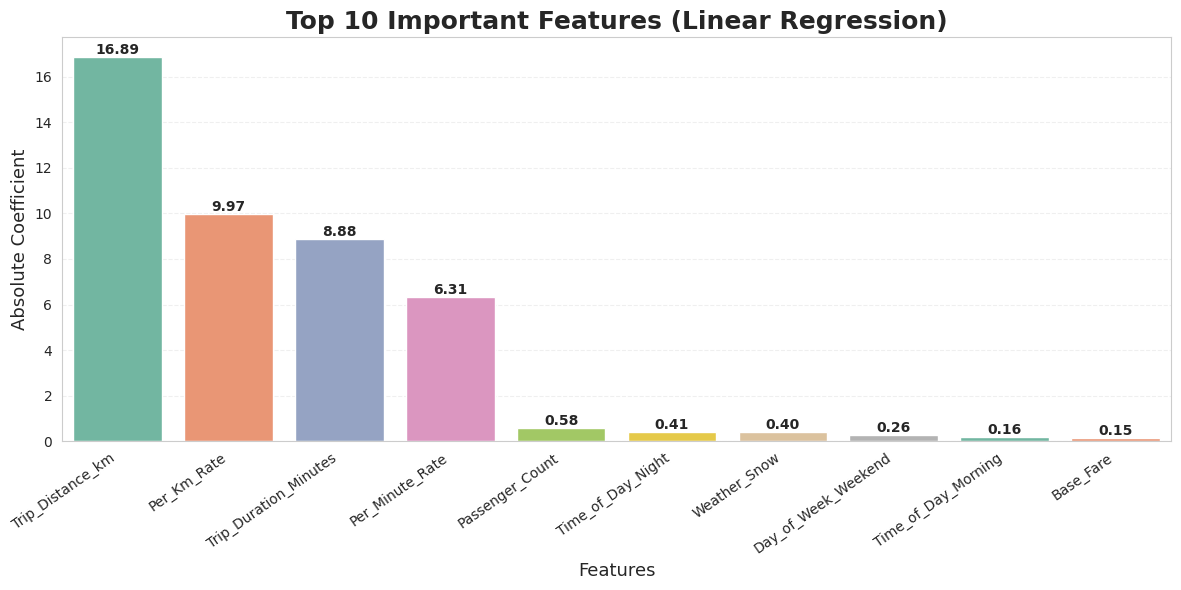

                  Feature  Coefficient  Importance
0        Trip_Distance_km    16.894242   16.894242
3             Per_Km_Rate     9.967939    9.967939
5   Trip_Duration_Minutes     8.880820    8.880820
4         Per_Minute_Rate     6.311434    6.311434
1         Passenger_Count     0.583188    0.583188
8       Time_of_Day_Night    -0.414045    0.414045
13           Weather_Snow     0.397648    0.397648
9     Day_of_Week_Weekend     0.261062    0.261062
7     Time_of_Day_Morning     0.159492    0.159492
2               Base_Fare     0.145080    0.145080


In [303]:

# Feature Importance using Linear Regression Coefficients
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_
})

# Absolute coefficient values
importance['Importance'] = importance['Coefficient'].abs()

# Sort by Importance
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 Features
top10 = importance.head(10)

# Plot
plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=top10,
    x='Feature',
    y='Importance',
    hue='Feature',
    palette='Set2',
    legend=False
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Top 10 Important Features (Linear Regression)',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Features', fontsize=13)
plt.ylabel('Absolute Coefficient', fontsize=13)

plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Display Feature Importance Table
print(top10)

# **Conclusion**

This project successfully developed a machine learning-based system to predict taxi trip prices using various trip-related features such as **trip distance, trip duration, passenger count, weather conditions, traffic conditions, base fare, per kilometer rate, and per minute rate.** The dataset was thoroughly preprocessed by handling missing values, treating outliers, encoding categorical variables, and preparing the data for model training.


Exploratory Data Analysis (EDA) provided valuable insights into the factors influencing taxi fares. Multiple visualizations revealed that trip distance, trip duration, and fare-related variables have the strongest impact on trip price, while weather and traffic conditions also contribute to fare variations.


Three regression models—**Linear Regression, Lasso Regression, and Ridge Regression**—were implemented and evaluated using **R² Score, MAE, MSE, and RMSE. Hyperparameter tuning** was performed using GridSearchCV with 5-fold Cross Validation to improve model performance and ensure reliable generalization.

Among all the models, Linear Regression delivered the best overall performance, achieving the highest R² Score (approximately 0.892) along with low prediction errors, making it the most suitable model for this dataset. Ridge Regression also produced competitive results after hyperparameter tuning, while Lasso Regression maintained stable performance with slightly lower accuracy.

The developed model can help taxi companies and ride-hailing platforms estimate fares more accurately, improve pricing transparency, optimize revenue management, and enhance customer satisfaction by providing reliable fare predictions. Overall, this project demonstrates that machine learning techniques can effectively support intelligent and data-driven taxi fare prediction systems.



### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***